In [1]:
import pandas as pd
import numpy as np
import os
import json
from scipy import constants
from pysr import PySRRegressor
import matplotlib.pyplot as plt
import sympy
import random

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
df = pd.read_pickle('/home/paolo/Na_dataset/diffusion.pckl.gzip', compression='gzip')

In [3]:
df

,structure,atoms,D_sim,D_300K,Ea,D0,r,D_sim_std,atoms_diffusion,diffusion_temps,...,VPA,NBI,RBI,weighted_electronegativity,FV,Na_spacing,Na_former_ratio,Na_anion_ratio,log_conductivity,logD
0,"[[-40.55755644 -31.11690268 -12.78408373] Na, ...","(Atom('Na', [-40.557556437030854, -31.11690267...","[1.4364625631071203e-07, 1.951308390440328e-06...",0.0,0.41481,-6.168029,-0.999534,"[2.0609274977491014e-08, 9.54751980775219e-08,...","[(Atom('Na', [16.4013, 25.9231, 16.2528], mome...","[500, 700, 900, 1100]",...,30.092044,0.672310,3.270586,2.779514,16.271870,5.009553,0.818182,0.239362,-6.802830,-22.213615
1,"[[-27.22272146 -48.08938883 -1.16173696] Na, ...","(Atom('Na', [-27.222721459416434, -48.08938883...","[5.260053344200803e-08, 4.0005952618958283e-07...",0.0,0.342211,-8.892149,-0.998229,"[1.170380927951024e-08, 3.5028882907097395e-08...","[(Atom('Na', [22.3934, 1.16212, 24.5241], mome...","[500, 700, 900, 1100]",...,28.802260,0.534658,1.160079,2.334804,9.578810,4.023160,0.851852,0.442308,-6.060846,-22.129469
2,"[[ -8.75124573 -35.84817417 1.41113688] Na, ...","(Atom('Na', [-8.751245728991412, -35.848174165...","[4.1491531541234836e-07, 2.9527838854461532e-0...",0.0,0.309818,-7.538836,-0.999465,"[4.712111654890927e-08, 1.5290730622277523e-07...","[(Atom('Na', [21.1725, 23.88, 1.00372], moment...","[500, 700, 900, 1100]",...,41.988188,0.418590,3.717974,2.110441,16.853349,4.911786,0.818182,0.387931,-4.053234,-19.523147
3,"[[ 5.90065301 -22.92956849 38.91278713] Na, ...","(Atom('Na', [5.900653007410151, -22.9295684907...","[3.644390884127098e-07, 2.282692400171146e-06,...",0.0,0.336138,-7.142088,-0.995077,"[2.3186241807603783e-08, 7.300603522025543e-08...","[(Atom('Na', [6.08525, 5.03001, 8.8188], momen...","[500, 700, 900, 1100]",...,44.180268,0.459960,12.327698,1.925347,13.252481,3.934283,2.846154,0.725490,-4.008862,-20.144502
4,"[[-19.7964428 -12.94618545 -22.08417706] Na, ...","(Atom('Na', [-19.79644280037215, -12.946185446...","[6.07698230883191e-08, 2.0869815246937256e-07,...",0.0,0.364908,-8.508542,-0.964053,"[1.548478587054459e-08, 3.1640692055019905e-08...","[(Atom('Na', [3.56707, 11.3108, 1.84764], mome...","[500, 700, 900, 1100]",...,21.846223,0.603340,1.635307,2.640404,9.327898,4.334335,0.492537,0.268293,-6.778690,-22.623812
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1299,"[[-45.16852818 -78.13919154 20.16465523] Na, ...","(Atom('Na', [-45.16852817712178, -78.139191541...","[3.297906167882209e-06, 1.8844573960753516e-05...",0.0,0.247734,-6.836898,-0.999179,"[9.792967224616881e-08, 3.9756638417401317e-07...","[(Atom('Na', [21.5008, 25.8636, 21.0757], mome...","[500, 700, 900, 1100]",...,51.279798,0.503579,9.309462,2.179317,22.017312,4.934985,1.828571,0.426667,-0.963887,-16.419663
1300,"[[ 27.78664333 -31.36783786 -24.2354884 ] Na, ...","(Atom('Na', [27.786643333402175, -31.367837857...","[9.156914520012137e-07, 5.1272087089512735e-06...",0.0,0.283584,-7.370918,-0.998882,"[4.870329640437488e-08, 1.4125831290277235e-07...","[(Atom('Na', [-1.42491, -1.18625, 5.80358], mo...","[500, 700, 900, 1100]",...,47.672488,0.587851,2.941818,2.144747,15.234442,3.981873,2.846154,0.755102,-2.240883,-18.340452
1301,"[[ 9.75765064 -22.01865729 14.7129202 ] Na, ...","(Atom('Na', [9.757650639408531, -22.0186572933...","[1.8383356363262403e-07, 1.3151544777712655e-0...",0.0,0.326622,-7.991634,-0.998646,"[1.634566553839534e-08, 5.978999364457793e-08,...","[(Atom('Na', [10.255, 6.08899, 15.3406], momen...","[500, 700, 900, 1100]",...,42.832632,0.457983,1.896230,1.958541,11.402734,3.826133,1.857143,0.764706,-4.406686,-20.625948
1302,"[[-39.37930038 -62.24010789 -38.49384248] Na, ...","(Atom('Na', [-39.37930038383808, -62.240107891...","[8.887014627167615e-07, 6.4231800149440465e-06...",0.0,0.297862,-7.015121,-0.999876,"[4.980311200542334e-08, 2.1804315739470145e-07...","[(Atom('Na', [22.5873, 0.0336273, 22.6647], mo...","[500, 700, 900, 1100]",...,39.816525,0.617591,3.275683,2.479636,17.560774,4.69335

In [4]:
# T = np.array(df['diffusion_temps'].to_list(), dtype=float).flatten()
# kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
# ln_D_all = np.log(np.array(df['D_sim'].to_list(), dtype=float).flatten()) 
# E = np.repeat(np.array(df['Ea'], dtype = 'float')[:],4)
# ln_D0 = np.array(df['D0'], dtype = 'float')[:]

# # Atomic fractions of a given element
# B = np.array(df['B%'], dtype = 'float')
# N = np.array(df['N%'], dtype = 'float')
# O = np.array(df['O%'], dtype = 'float')
# F = np.array(df['F%'], dtype = 'float')
# Na = np.array(df['Na%'], dtype = 'float')
# Al = np.array(df['Al%'], dtype = 'float')
# Si = np.array(df['Si%'], dtype = 'float')
# P = np.array(df['P%'], dtype = 'float')
# S = np.array(df['S%'], dtype = 'float')
# Cl = np.array(df['Cl%'], dtype = 'float')
# Ge = np.array(df['Ge%'], dtype = 'float')
# Br = np.array(df['Br%'], dtype = 'float')
# I = np.array(df['I%'], dtype = 'float')]

# density = np.array(df['density'], dtype = 'float')
# # Average Atomic Volume
# AAV = np.array(df['AAV'], dtype = 'float')
# # Packing fraction
# PF = np.array(df['PF'], dtype = 'float')
# # set-of-non-Na-atoms bond ionicity
# SBI = np.array(df['SBI'], dtype = 'float')
# # Volume per anion
# VPA = np.array(df['VPA'], dtype = 'float')
# # Na bond ionicity
# NBI = np.array(df['NBI'], dtype = 'float')
# # Ratio of NBI and SBI
# RBI = np.array(df['RBI'], dtype = 'float')
# # Weighted electronegativity
# WE = np.array(df['weighted_electronegativity'], dtype = 'float')

In [5]:
def arr_repeat(col, n=4):
    return np.repeat(np.array(df[col], dtype='float'), n)

In [6]:
def initialize(prune_flag = False, med_flag = False):
    '''
    Initializes the variables with the option of pruning and choosing the threshold
    '''
    kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
    ln_D_all = np.log(np.array(df['D_sim'].to_list(), dtype=float).flatten())
    # Pruning procedure
    if (prune_flag == True):
        if (med_flag == True):
            med =  np.median(ln_D_all).round()
            ln_D = ln_D_all[ln_D_all>med]
            ind = np.where(ln_D_all > med)[0]
        else:
            med = -15
            ln_D = ln_D_all[ln_D_all>-15]
            ind = np.where(ln_D_all > -15)[0]
    else:
        ln_D = ln_D_all
        ind = np.where(ln_D_all)
        med = -20
    
    return {
        "med" : med,
        "ln_D_all" : ln_D_all,
        "ln_D" : ln_D,
        "T" : np.array(df['diffusion_temps'].to_list(), dtype=float).flatten()[ind],
        "E" : arr_repeat('Ea')[ind],
        "ln_D0": arr_repeat("D0")[ind],

        # Atomic fractions
        "B":  arr_repeat("B%")[ind],
        "N":  arr_repeat("N%")[ind],
        "O":  arr_repeat("O%")[ind],
        "F":  arr_repeat("F%")[ind],
        "Na": arr_repeat("Na%")[ind],
        "Al": arr_repeat("Al%")[ind],
        "Si": arr_repeat("Si%")[ind],
        "P":  arr_repeat("P%")[ind],
        "S":  arr_repeat("S%")[ind],
        "Cl": arr_repeat("Cl%")[ind],
        "Ge": arr_repeat("Ge%")[ind],
        "Br": arr_repeat("Br%")[ind],
        "I":  arr_repeat("I%")[ind],
    
        "density": arr_repeat("density")[ind],
    
        # Structural / electronic descriptors
        "AAV": arr_repeat("AAV")[ind],
        "PF":  arr_repeat("PF")[ind],
        "SBI": arr_repeat("SBI")[ind],
        "VPA": arr_repeat("VPA")[ind],
        "NBI": arr_repeat("NBI")[ind],
        "RBI": arr_repeat("RBI")[ind],
        "WE":  arr_repeat("weighted_electronegativity")[ind],
    }

In [7]:
data = initialize(prune_flag = True)
if any(data['ln_D'] < -15):
    print('error')
else:
    print('ok')

ok


In [46]:
# T = np.array(df['diffusion_temps'].to_list(), dtype=float).flatten()
# kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
# ln_D_all = np.log(np.array(df['D_sim'].to_list(), dtype=float).flatten()) 

# E = arr_repeat('Ea')
# ln_D0 = arr_repeat('D0')
# # Atomic fractions
# B  = arr_repeat('B%')
# N  = arr_repeat('N%')
# O  = arr_repeat('O%')
# F  = arr_repeat('F%')
# Na = arr_repeat('Na%')
# Al = arr_repeat('Al%')
# Si = arr_repeat('Si%')
# P  = arr_repeat('P%')
# S  = arr_repeat('S%')
# Cl = arr_repeat('Cl%')
# Ge = arr_repeat('Ge%')
# Br = arr_repeat('Br%')
# I  = arr_repeat('I%')

# density = arr_repeat('density')

# # Structural / electronic descriptors
# AAV = arr_repeat('AAV')
# PF  = arr_repeat('PF')
# SBI = arr_repeat('SBI')
# VPA = arr_repeat('VPA')
# NBI = arr_repeat('NBI')
# RBI = arr_repeat('RBI')
# WE  = arr_repeat('weighted_electronegativity')

In [10]:
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
data = initialize(prune_flag = False)
lnDvsT = pd.DataFrame({
    "sample_id": [f"s{j+1}" for j in range(len(data['ln_D']))], 
    "E": data['E'],
    "T": kb*data['T'],
    "rho": data['density'],
    "AAV": data['AAV'],
    "PF": data['PF'],
    "VPA": data['VPA'],
    "RBI": data['RBI'],
    "WE": data['WE'],
    "B": data['B'],
    "N": data['N'],
    "S": data['S'],
    "O": data['O'],
    "F": data['F'],
    "Na": data['Na'],
    "Al": data['Al'],
    "Si": data['Si'],
    "P": data['P'],
    "Cl": data['Cl'],
    "Ge": data['Ge'],
    "Br": data['Br'],
    "I": data['I'],
    "ln_D": data['ln_D']
})

In [12]:
data['ln_D'], data['ln_D_all']

(array([-15.75591211, -13.14701044, -11.4666276 , ..., -11.2789572 ,
        -10.23266635,  -9.59023232]),
 array([-15.75591211, -13.14701044, -11.4666276 , ..., -11.2789572 ,
        -10.23266635,  -9.59023232]))

In [16]:
# lnDvsT = pd.DataFrame({"sample_id": [f"s{i+1}" for i in range(len(ln_D_all))], 'E': E, 'T': kb*T, 'rho': density, 'AAV': AAV, 'PF': PF, 'VPA': VPA,  'RBI': RBI, 'WE': WE, 'B': B, 'N': N, 
#                        'S': S, 'O': O, 'F': F, 'Na': Na, 'Al': Al, 'Si': Si, 'P': P, 'Cl': Cl, 'Ge': Ge, 'Br': Br, 'I': I,
#                        'ln_D': ln_D_all}) 

In [53]:
n_feat = 21
lnDvsT.to_csv(f"/home/paolo/Thesis/Na/data/temp/Na_lndiff{n_feat}_temp.csv", index=False)
data_file = f"/home/paolo/Thesis/Na/data/temp/Na_lndiff{n_feat}_temp.csv"
os.environ["SISSOPP_TUT_DAT_FILE"] = data_file

In [49]:
# Try the fit with the exact functional form
rung = 2
Diff_json = {
    'data_file': data_file,
     'property_key': 'ln_D',
     'desc_dim': 1,
     'n_sis_select': 10,
     'max_rung': rung,
     'calc_type': 'regression',
     'min_abs_feat_val': 1e-05,
     'max_abs_feat_val': 1e8,
     'n_residual': 10,
     'n_models_store': 10,
     'leave_out_frac': 0.0,
     'leave_out_inds': [],
     'opset': ['exp', 'add', 'sub', 'mult', 'div', 'sin', 'cos']
}
json.dump(Diff_json, open(f"/home/paolo/Thesis/Na/data/temp/lndiff{n_feat}_{rung}_temps.json", "w"), indent=4)

In [ ]:
# Rung=2 Features=2, Time=instant 'E': E, 'T': T 
# time input_parsing: 0.0380462 s
# Time to generate feat space: 0.009831 s
# Projection time: 0.0027044 s
# Time to get best features on rank : 0.0016178 s
# |---Complete final combination/selection from all ranks: 0.0008116 s
# Time for SIS: 0.0063169 s
# Time for l0-norm: 0.0259271 s
# Train RMSE: 0.89601 Unitless
# c0 + a0 * (cos(E) * (E / T))

In [ ]:
# 0             0.75951972139711299     cos((E / T))
# 1             0.765984669814624208    (exp(E) * (E / T))
# 2             0.783277351504715558    ((E / T) / exp(E))
# 3             0.788028985397540627    (E / (E - T))
# 4             0.788038399572457915    sin((E / T))
# 5             0.788047754956455404    (T / (E + T))
# 6             0.78911271687210871     (sin(E) / (E - T))
# 7             0.789121488164012619    (sin(E) / T)
# 8             0.789130207222019875    (sin(E) / (E + T))
# 9             0.790117496458415669    (cos(E) * (E / T))

In [ ]:
# Rung=2 Features=21 'E': E, 'T': T, 'rho': density, 'AAV': AAV, 'PF': PF, 'VPA': VPA,  'RBI': RBI, 'WE': WE, 'B': B, 'N': N, 
                       # 'S': S, 'O': O, 'F': F, 'Na': Na, 'Al': Al, 'Si': Si, 'P': P, 'Cl': Cl, 'Ge': Ge, 'Br': Br, 'I': I
# time input_parsing: 0.168 s
# Time to generate feat space: 13.7864 s
# Projection time: 4.10064 s
# Time to get best features on rank : 0.003699 s
# |---Complete final combination/selection from all ranks: 0.0015007 s
# Time for SIS: 4.22996 s
# Time for l0-norm: 0.0235055 s
# Train RMSE: 0.623355 Unitless
# c0 + a0 * (exp(O) / (WE * T))

In [15]:
# 0             0.867252236934867082    (cos(Cl) / (AAV * T))
# 1             0.867459891810014927    (cos(N) / (AAV * T))
# 2             0.86758199247674439     (cos(P) / (AAV * T))
# 3             0.867613621439805804    (exp(N) / (AAV * T))
# 4             0.868149070795355748    (cos(E) / (AAV * T))
# 5             0.869052829353970324    (exp(I) / (AAV * T))
# 6             0.871691301787004269    (cos(F) / (AAV * T))
# 7             0.874664028574587471    (cos(B) / (AAV * T))
# 8             0.881757842918467816    (cos(O) / (AAV * T))
# 9             0.898416890945752389    (exp(O) / (WE * T))

In [ ]:
# adding kb

In [ ]:
# Rung=2 Features=21 'E': E, 'T': kb*T, 'rho': density, 'AAV': AAV, 'PF': PF, 'VPA': VPA,  'RBI': RBI, 'WE': WE, 'B': B, 'N': N, 
                       # 'S': S, 'O': O, 'F': F, 'Na': Na, 'Al': Al, 'Si': Si, 'P': P, 'Cl': Cl, 'Ge': Ge, 'Br': Br, 'I': I
# time input_parsing: 0.163957 s
# Time to generate feat space: 13.6781 s
# Projection time: 3.97649 s
# Time to get best features on rank : 0.0004192 s
# |---Complete final combination/selection from all ranks: 0.0004917 s
# Time for SIS: 4.104 s
# Time for l0-norm: 0.0168488 s
# Train RMSE: 0.620969 Unitless
# c0 + a0 * ((O / E) + (E / T))
# Task   a0                      c0
# all , -9.538007909579611e-01, -6.998167295788756e+00,

In [61]:
data['ln_D'].size

5208

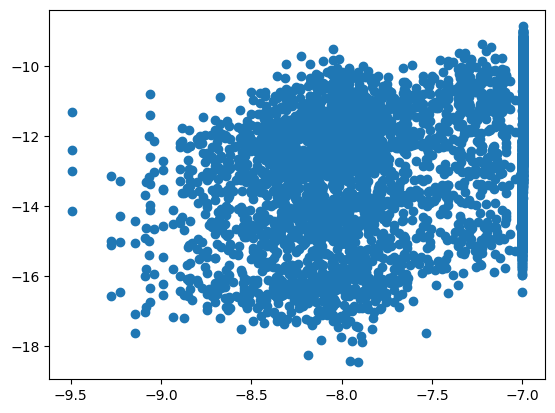

In [69]:
a0 = -9.538007909579611e-01                   
c0 = -6.998167295788756e+00
fct = c0 + a0 * ((data['O'] / data['E']) + (data['E'] / data['T']))
plt.scatter(fct, data['ln_D'])
#plt.plot([-13,-9], [-13, -9], color = 'red')
plt.show()

In [ ]:
# Pruning and adding kb

In [ ]:
# Rung=2 Features=21 'E': E, 'T': kb*T, 'rho': density, 'AAV': AAV, 'PF': PF, 'VPA': VPA,  'RBI': RBI, 'WE': WE, 'B': B, 'N': N, 
                       # 'S': S, 'O': O, 'F': F, 'Na': Na, 'Al': Al, 'Si': Si, 'P': P, 'Cl': Cl, 'Ge': Ge, 'Br': Br, 'I': I
# Pruned of low diff syst ln(D)>-15
# time input_parsing: 0.144828 s
# Time to generate feat space: 13.1398 s
# Projection time: 3.16025 s
# Time to get best features on rank : 0.0003879 s
# |---Complete final combination/selection from all ranks: 0.0004427 s
# Time for SIS: 3.29 s
# Time for l0-norm: 0.0133702 s
# Train RMSE: 0.559443 Unitless
# c0 + a0 * ((VPA * T) * (Al - WE))
# Task   a0                      c0
# all , -7.857852423879554e-01, -1.687751294812731e+01,